# 01 - Data Exploration: IMDB Spoiler Dataset

Before training any model, we need to understand our data. This notebook explores:
1. What the data looks like (structure, fields, types)
2. Class distribution (how many spoilers vs non-spoilers)
3. Text characteristics (length, patterns)
4. What makes spoiler text different from non-spoiler text

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

# Make plots look clean
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Matplotlib is building the font cache; this may take a moment.


## 1. Load the Data

The IMDB dataset comes as line-delimited JSON (one JSON object per line).
Each line is a single review.

In [2]:
# Load reviews - each line is a separate JSON object
reviews = pd.read_json("../data/raw/IMDB_reviews.json", lines=True)
print(f"Loaded {len(reviews):,} reviews")
print(f"Columns: {list(reviews.columns)}")
print(f"Memory usage: {reviews.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded 573,913 reviews
Columns: ['review_date', 'movie_id', 'user_id', 'is_spoiler', 'review_text', 'rating', 'review_summary']
Memory usage: 1051.4 MB


In [3]:
# Look at the first few rows to understand the structure
reviews.head(3)

,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film


In [7]:
# Data types and null counts
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573913 entries, 0 to 573912
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   review_date     573913 non-null  object
 1   movie_id        573913 non-null  object
 2   user_id         573913 non-null  object
 3   is_spoiler      573913 non-null  bool  
 4   review_text     573913 non-null  object
 5   rating          573913 non-null  int64 
 6   review_summary  573913 non-null  object
dtypes: bool(1), int64(1), object(5)
memory usage: 26.8+ MB


## 2. Class Distribution

This is the first thing to check in any classification task.
If the classes are heavily imbalanced, we'll need to account for that during training.

In [ ]:
# Count spoiler vs non-spoiler
spoiler_counts = reviews["is_spoiler"].value_counts()
spoiler_pct = reviews["is_spoiler"].value_counts(normalize=True) * 100

print("Class distribution:")
print(f"  Non-spoiler (False): {spoiler_counts[False]:>10,} ({spoiler_pct[False]:.1f}%)")
print(f"  Spoiler     (True):  {spoiler_counts[True]:>10,} ({spoiler_pct[True]:.1f}%)")


Class distribution:
  Non-spoiler (False): 422989 (73.7%)
  Spoiler     (True):     150,924 (26.3%)


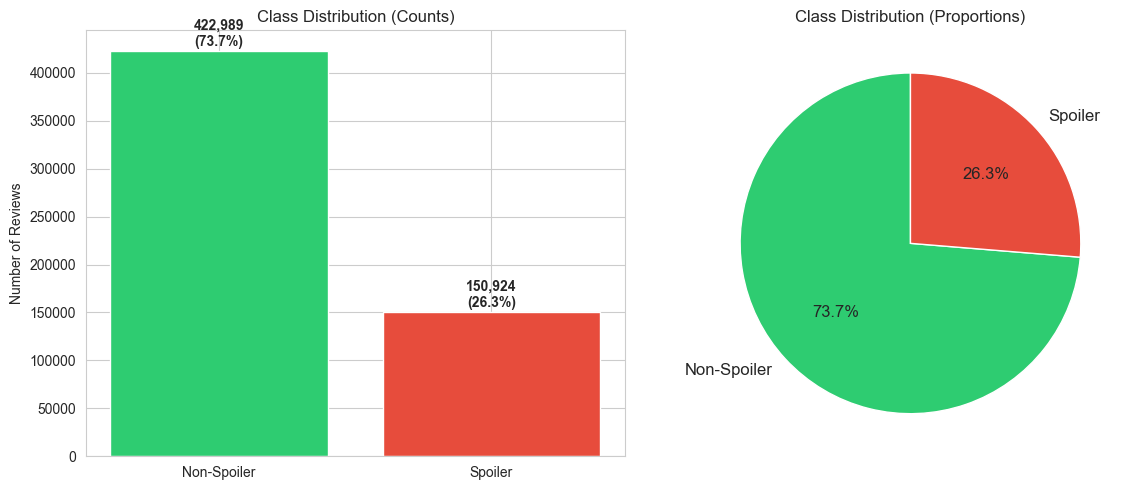


Imbalance ratio: 2.80:1 (non-spoiler to spoiler)


In [13]:
# Visualize the class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["Non-Spoiler", "Spoiler"], spoiler_counts.values, color=colors)
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Class Distribution (Counts)")
for i, (count, pct) in enumerate(zip(spoiler_counts.values, spoiler_pct.values)):
    axes[0].text(i, count + 5000, f"{count:,}\n({pct:.1f}%)", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(spoiler_counts.values, labels=["Non-Spoiler", "Spoiler"], colors=colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Distribution (Proportions)")

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {spoiler_counts[False] / spoiler_counts[True]:.2f}:1 (non-spoiler to spoiler)")

## 3. Review Length Analysis

Text length matters for our model. DistilBERT has a max input of 512 tokens.
Let's see how long these reviews are and whether spoiler reviews differ in length.

In [ ]:
# Calculate review lengths (in characters and approximate word count)
reviews["char_length"] = reviews["review_text"].str.len()
reviews["word_count"] = reviews["review_text"].str.split().str.len()

print("Overall review length statistics (words):")

print(f"describe", reviews["word_count"].describe().to_string())

print(f"nodescribe", reviews["word_count"])

Overall review length statistics (words):
describe count    573913.000000
mean        258.844651
std         195.303807
min           1.000000
25%         131.000000
50%         189.000000
75%         321.000000
max        2675.000000
nodescribe 0         843
1         223
2         250
3         741
4         829
         ... 
573908     52
573909     54
573910    202
573911     89
573912    177
Name: word_count, Length: 573913, dtype: int64


In [22]:
# Compare lengths: spoiler vs non-spoiler
print("Word count by class:")
print(reviews.groupby("is_spoiler")["word_count"].describe().round(1).to_string())

Word count by class:
               count   mean    std  min    25%    50%    75%     max
is_spoiler                                                          
False       422989.0  231.8  176.7  1.0  124.0  170.0  279.0  2675.0
True        150924.0  334.6  223.1  1.0  166.0  260.0  435.0  2562.0


/var/folders/bf/_txfdr4n7dbf1hz_7tkfbgjr0000gn/T/ipykernel_38970/488356491.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=["Non-Spoiler", "Spoiler"], patch_artist=True)


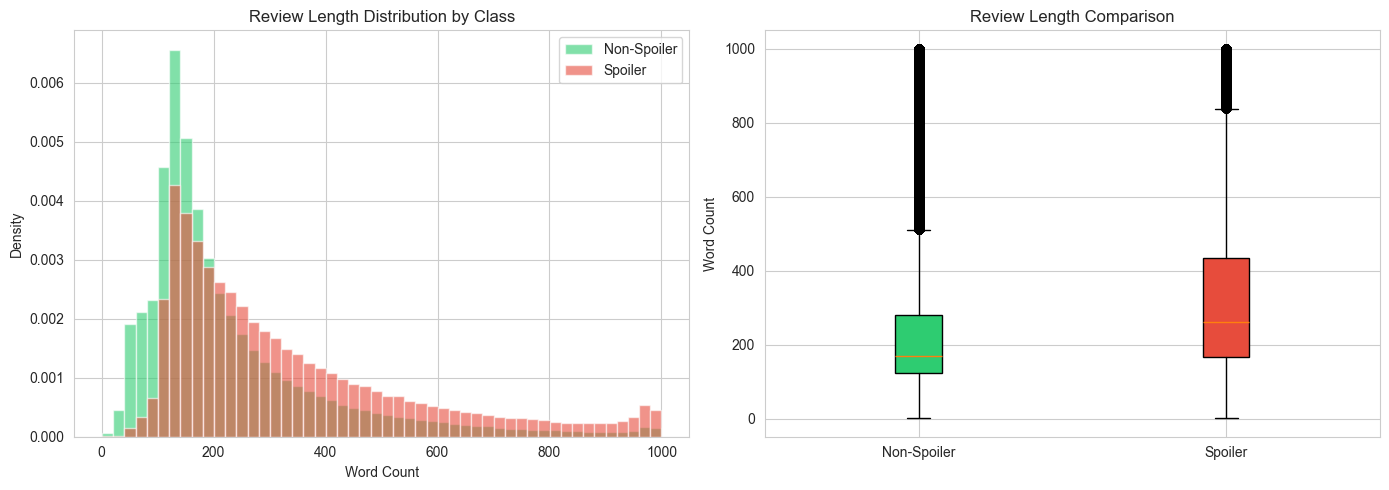

In [37]:
# Visualize length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of word counts (capped at 1000 for readability)
for is_spoiler, color, label in [(False, "#2ecc71", "Non-Spoiler"), (True, "#e74c3c", "Spoiler")]:
    subset = reviews[reviews["is_spoiler"] == is_spoiler]["word_count"].clip(upper=1000)
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)

axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Density")
axes[0].set_title("Review Length Distribution by Class")
axes[0].legend()

# Box plot comparison
data_to_plot = [
    reviews[reviews["is_spoiler"] == False]["word_count"].clip(upper=1000),
    reviews[reviews["is_spoiler"] == True]["word_count"].clip(upper=1000)
]
bp = axes[1].boxplot(data_to_plot, labels=["Non-Spoiler", "Spoiler"], patch_artist=True)
bp["boxes"][0].set_facecolor("#2ecc71")
bp["boxes"][1].set_facecolor("#e74c3c")
axes[1].set_ylabel("Word Count")
axes[1].set_title("Review Length Comparison")

plt.tight_layout()
plt.show()

### 3b. Spoiler Rate by Sentiment

The dataset includes each reviewer's rating (1-10). We can group these into
negative (1-4), neutral (5-6), and positive (7-10) sentiment to see if
spoiler behavior differs by how much someone liked the movie.

In [66]:
# Categorize reviews by sentiment based on rating
def rating_to_sentiment(rating):
    if rating <= 4:
        return "Negative (1-4)"
    elif rating <= 6:
        return "Neutral (5-6)"
    else:
        return "Positive (7-10)"

reviews["sentiment"] = reviews["rating"].apply(rating_to_sentiment)

# Count reviews and spoiler rate per sentiment group
sentiment_stats = reviews.groupby("sentiment").agg(
    total=("is_spoiler", "count"),
    spoilers=("is_spoiler", "sum"),
).sort_index()
sentiment_stats["spoiler_rate"] = (sentiment_stats["spoilers"] / sentiment_stats["total"] * 100).round(1)

print("Spoiler rate by sentiment:")
print(sentiment_stats.to_string())
print(f"\n--> This tells us whether people who disliked a movie are more/less likely to post spoilers.")

Spoiler rate by sentiment:
                  total  spoilers  spoiler_rate
sentiment                                      
Negative (1-4)   125262     40059          32.0
Neutral (5-6)     74458     22641          30.4
Positive (7-10)  374193     88224          23.6

--> This tells us whether people who disliked a movie are more/less likely to post spoilers.


/var/folders/bf/_txfdr4n7dbf1hz_7tkfbgjr0000gn/T/ipykernel_38970/2676110465.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_sentiment, labels=["Negative", "Neutral", "Positive"], patch_artist=True)


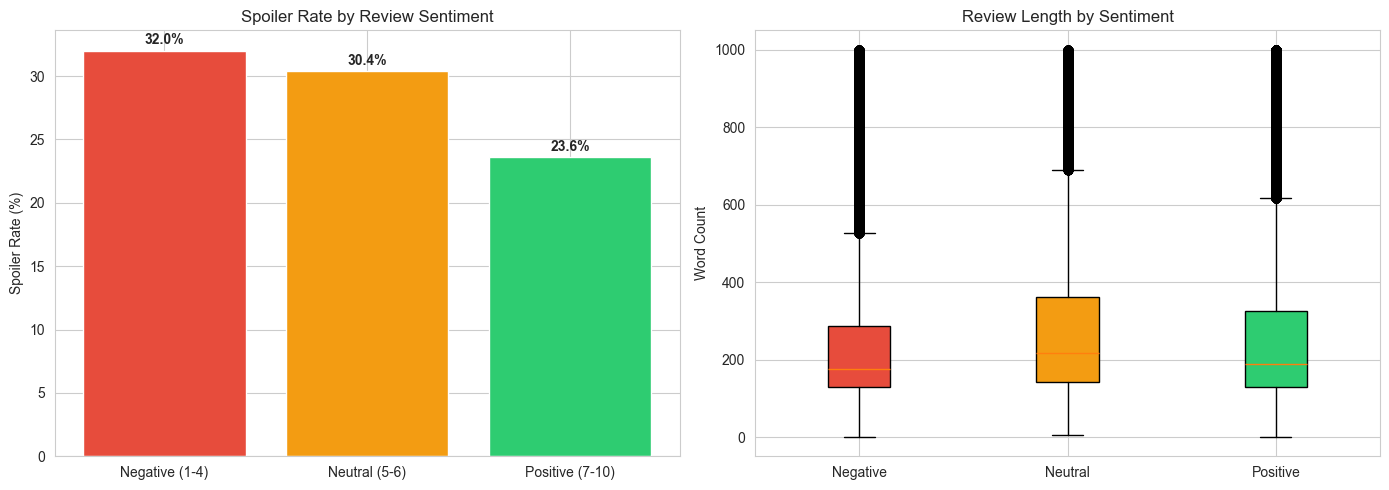

In [69]:
# Visualize: spoiler rate by sentiment + review length by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: spoiler rate per sentiment
colors_sent = ["#e74c3c", "#f39c12", "#2ecc71"]
sentiments = ["Negative (1-4)", "Neutral (5-6)", "Positive (7-10)"]
spoiler_rates = [sentiment_stats.loc[s, "spoiler_rate"] for s in sentiments]

axes[0].bar(sentiments, spoiler_rates, color=colors_sent)
axes[0].set_ylabel("Spoiler Rate (%)")
axes[0].set_title("Spoiler Rate by Review Sentiment")
for i, rate in enumerate(spoiler_rates):
    axes[0].text(i, rate + 0.5, f"{rate}%", ha="center", fontweight="bold")

# Box plot: review length by sentiment
data_by_sentiment = [
    reviews[reviews["sentiment"] == s]["word_count"].clip(upper=1000)
    for s in sentiments
]
bp = axes[1].boxplot(data_by_sentiment, labels=["Negative", "Neutral", "Positive"], patch_artist=True)
for patch, color in zip(bp["boxes"], colors_sent):
    patch.set_facecolor(color)
axes[1].set_ylabel("Word Count")
axes[1].set_title("Review Length by Sentiment")

plt.tight_layout()
plt.show()

## 4. Sample Reviews

Nothing beats reading actual examples. Let's look at a few spoiler and non-spoiler reviews
to build intuition for what the model needs to learn.

In [ ]:
    # old code, ok but slower approach.
# countsmalls = 0
# for i, row in reviews[reviews["is_spoiler"] == True].iterrows():
#     if len(row["review_text"]) < 300:
#         countsmalls += 1
# print(countsmalls)

countsmalls = (reviews[reviews["is_spoiler"] == True]["char_length"] < 300).sum()
print(countsmalls)


290


In [81]:
# # Show 3 random spoiler reviews
# print("=" * 80)
# print("SPOILER REVIEWS (is_spoiler=True)")
# print("=" * 80)
# for i, row in reviews[reviews["is_spoiler"] == True].iterrows():
#     # show only if review is less than 300 chars
#     if len(row["review_text"]) < 300:   
#         # Show first 300 chars to keep it readable
#         # text_preview = row["review_text"][:300] + "..." if len(row["review_text"]) > 300 else row["review_text"]
#         text_preview = row["review_text"][:300] + "..." if len(row["review_text"]) > 300 else row["review_text"]
#         print(f"\n[Movie: {row['movie_id']}]")
#         print(f"{text_preview}")
#         print("-" * 80)


short_spoilers = reviews[(reviews["is_spoiler"] == True) & (reviews["char_length"] < 300)]
print(f"Found {len(short_spoilers)} short (char_length < 300) spoiler reviews\n")

for i, row in short_spoilers.sample(10, random_state=43).iterrows():
    print(f"[Movie: {row['movie_id']}]")
    print(row["sentiment"])
    print(row["review_text"])
    print("-" * 80)

Found 290 short (char_length < 300) spoiler reviews

[Movie: tt2119532]
Positive (7-10)
Finally a war film which don't shows the war like an other movies. Indeed , although the war is represented the main character isn't a soldier he is a Christian who want help people without a weapon. i think this film represented the favorable quoted of the war ; the human quoted.
--------------------------------------------------------------------------------
[Movie: tt1837492]
Positive (7-10)
Binge watched the series in one night. Contrary to popular opinion, I don't think it glorifies suicide, but tries to give us a glimpse into the most troubled minds, those which believe with such conviction that they have no way out, except suicide. It is a must watch, quite beautifully presented.
--------------------------------------------------------------------------------
[Movie: tt0110912]
Positive (7-10)
the drugs made the fiction , the toaster killed Vincent Vega , Jules Winnfield is a real gangster , 

In [77]:
# Show 3 random non-spoiler reviews
print("="*80)
print("NON-SPOILER REVIEWS (is_spoiler=False)")
print("="*80)
for i, row in reviews[reviews["is_spoiler"] == False].sample(3, random_state=42).iterrows():
    text_preview = row["review_text"][:300] + "..." if len(row["review_text"]) > 300 else row["review_text"]
    print(f"\n[Movie: {row['movie_id']}]")
    print(f"{text_preview}")
    print("-"*80)

NON-SPOILER REVIEWS (is_spoiler=False)

[Movie: tt0106697]
Sly Vs. Snipes The action is tremendous, especially the one on one scene in the museum. Great overall cast and it did have its humorous moments about the three seashells. Snipes is great as the martial arts bad guy.
--------------------------------------------------------------------------------

[Movie: tt1568346]
As a huge fan of the books and original movie in 2009 I had high hopes for the newest addition and was in no way disappointed. The movie was in fact incredible, with all the suspense and vast intelligence of the book and 2009 film this remake has easily made itself a contender for the best film of t...
--------------------------------------------------------------------------------

[Movie: tt0332379]
7 years on and this still ranks as Black's best. Thankfully he has a number of restraints on him as he isn't the only driving force here. White is a good comedic writer, Linklater is a talented director that has handled

## 5. Token Length Estimation

Our model (DistilBERT) works with tokens, not words. A token is roughly 0.75 words.
DistilBERT has a max input of 512 tokens, so we need to know how much data we'll lose
by truncating.

In [78]:
# Estimate token count (rough: ~1.3 tokens per word for English text)
reviews["est_tokens"] = (reviews["word_count"] * 1.3).astype(int)

for max_tokens in [128, 256, 512]:
    fits = (reviews["est_tokens"] <= max_tokens).mean() * 100
    print(f"Reviews fitting in {max_tokens} tokens: {fits:.1f}%")

print(f"\n--> We'll use max_length=256 as a good balance of coverage and training speed.")

Reviews fitting in 128 tokens: 10.5%
Reviews fitting in 256 tokens: 52.6%
Reviews fitting in 512 tokens: 82.0%

--> We'll use max_length=256 as a good balance of coverage and training speed.


## 6. Key Takeaways

### Dataset Findings
What we learned from exploring the IMDB spoiler dataset.

### Role of This Dataset in the Project

During exploration, we identified that the IMDB dataset detects **spoiler content within text**
(e.g., "wolverine died at the end"). However, our project's primary goal is to assess whether
a **YouTube trailer contains spoilers**, and the most useful YouTube comments for this are
**meta-commentary** (e.g., "this trailer showed way too much") rather than plot reveals.

**Key insights that shaped the project direction:**
1. IMDB spoiler labels are noisy -- some reviews are mislabeled by users
2. Spoiler self-announcements ("SPOILER ALERT") serve different purposes: in IMDB reviews it's
   a courtesy warning before the reviewer's own spoiler, but in YouTube comments it could be a
   warning that the trailer itself is spoilery -- a high-value signal we must NOT strip out
3. Detecting "this trailer is spoilery" (opinion/warning) is a different NLP task than detecting
   actual plot reveals in text
4. Premises vs. spoilers (e.g., a death that opens the movie vs. a twist ending) are
   context-dependent and hard for a content-based model alone to distinguish

**Conclusion:** This IMDB dataset will serve as a **secondary signal** (detecting actual spoiler
content in comments), not the primary skeleton of the project. The project pipeline will be:
1. Keyword heuristics for trailer spoiler warnings (baseline)
2. Zero-shot classification for meta-commentary detection
3. Custom-labeled YouTube comment dataset from known spoilery trailers
4. IMDB fine-tuned model as an additional signal for detecting plot reveals

In [82]:
print("IMDB DATASET FINDINGS")
print("=" * 60)
print(f"Total reviews:       {len(reviews):,}")
print(f"Spoiler reviews:     {spoiler_counts[True]:,} ({spoiler_pct[True]:.1f}%)")
print(f"Non-spoiler reviews: {spoiler_counts[False]:,} ({spoiler_pct[False]:.1f}%)")
print(f"Median word count:   {reviews['word_count'].median():.0f} words")
print()
print("OBSERVATIONS")
print("=" * 60)
print("1. Class imbalance: ~3:1 ratio (non-spoiler to spoiler)")
print("2. Spoiler reviews tend to be longer -> length alone is a weak signal")
print("3. Labels are noisy -- some reviews are mislabeled")
print("4. Self-announcements ('SPOILER ALERT') have different meaning in reviews vs YouTube")
print("5. Premise events vs actual spoilers are hard to distinguish without movie context")
print()
print("ROLE IN PROJECT")
print("=" * 60)
print("This dataset is a SECONDARY signal for the project.")
print("It will be used to train a model that detects plot-reveal content in text.")
print("The PRIMARY approach for YouTube trailer spoiler detection will be:")
print("  1. Keyword heuristics (baseline)")
print("  2. Zero-shot classification (meta-commentary detection)")
print("  3. Custom YouTube comment dataset from known spoilery trailers")
print("  4. IMDB fine-tuned model (additional signal for actual plot reveals)")

IMDB DATASET FINDINGS
Total reviews:       573,913
Spoiler reviews:     150,924 (26.3%)
Non-spoiler reviews: 422,989 (73.7%)
Median word count:   189 words

OBSERVATIONS
1. Class imbalance: ~3:1 ratio (non-spoiler to spoiler)
2. Spoiler reviews tend to be longer -> length alone is a weak signal
3. Labels are noisy -- some reviews are mislabeled
4. Self-announcements ('SPOILER ALERT') have different meaning in reviews vs YouTube
5. Premise events vs actual spoilers are hard to distinguish without movie context

ROLE IN PROJECT
This dataset is a SECONDARY signal for the project.
It will be used to train a model that detects plot-reveal content in text.
The PRIMARY approach for YouTube trailer spoiler detection will be:
  1. Keyword heuristics (baseline)
  2. Zero-shot classification (meta-commentary detection)
  3. Custom YouTube comment dataset from known spoilery trailers
  4. IMDB fine-tuned model (additional signal for actual plot reveals)
